In [1]:
Machine Learning:  Wine Quality dataset
This code uses the dataset analysing it predicting outcomes based on user behavior,
optimizing conversion rates, and ranking items or users effectively.
Algorithms used:  Logistic regresion, decision trees, gradient boosting, and random forest.

SyntaxError: invalid syntax (3532160309.py, line 1)

In [2]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns

print ("libraries ready")

libraries ready


In [3]:
sns.set()
print("sns ready")

sns ready


In [4]:
# 1) Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")

print ("dataset ready")

dataset ready


In [5]:
# 2) Prepare features / target
# Binarize quality: 7+ = good (1), else not good (0)
df["target"] = (df["quality"] >= 7).astype(int)
X = df.drop(columns=["quality", "target"])
y = df["target"]

print("Shape:", X.shape)
print("Class balance:\n", y.value_counts())


Shape: (1599, 11)
Class balance:
 target
0    1382
1     217
Name: count, dtype: int64


In [6]:
# 3) Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

print("train/test complete")

train/test complete


In [7]:
# 4) Define models with pipelines (scaling for LR)
models = {
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
}

print("definition complete")

definition complete


---LogisticRegression---
              precision    recall  f1-score   support

           0     0.9091    0.9747    0.9408       277
           1     0.6957    0.3721    0.4848        43

    accuracy                         0.8938       320
   macro avg     0.8024    0.6734    0.7128       320
weighted avg     0.8804    0.8938    0.8795       320

---DecisionTree---
              precision    recall  f1-score   support

           0     0.9487    0.9350    0.9418       277
           1     0.6170    0.6744    0.6444        43

    accuracy                         0.9000       320
   macro avg     0.7829    0.8047    0.7931       320
weighted avg     0.9041    0.9000    0.9019       320

---RandomForest---
              precision    recall  f1-score   support

           0     0.9450    0.9928    0.9683       277
           1     0.9310    0.6279    0.7500        43

    accuracy                         0.9437       320
   macro avg     0.9380    0.8103    0.8592       320
weighted av

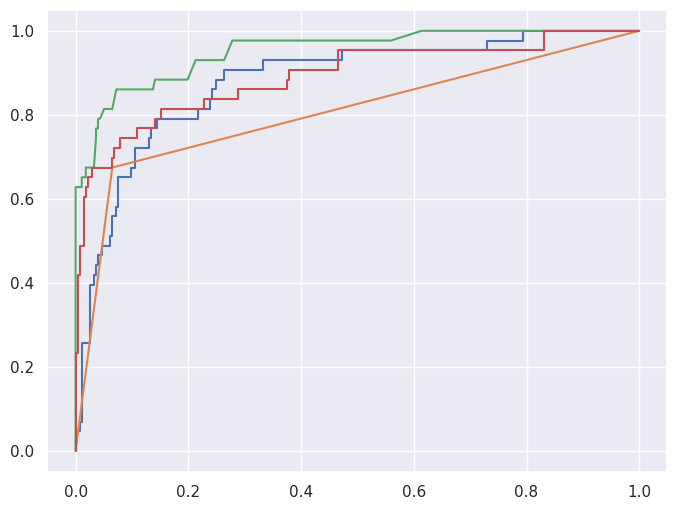

In [11]:
# 5) Train, evaluate, and plot ROC
plt.figure(figsize=(8,6))
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        y_score = model.decision_function(X_test)
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_score) if len(np.unique(y_test))>1 else np.nan
    results.append((name, acc, roc))
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc:.3f})")
    print(f"---{name}---")
    print(classification_report(y_test, y_pred, digits=4))


/tmp/ipykernel_13439/2341200492.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


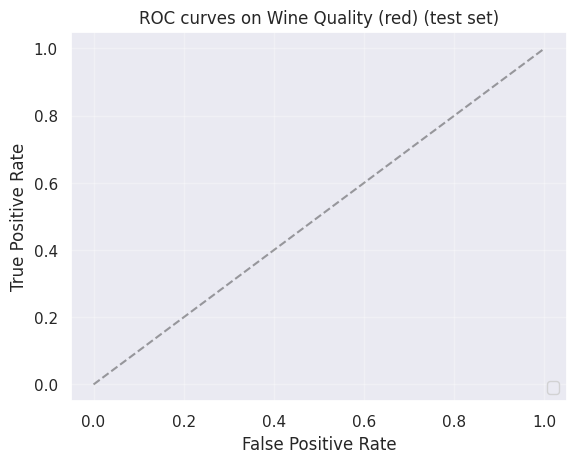

In [12]:
plt.plot([0,1],[0,1],"k--",alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves on Wine Quality (red) (test set)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()



In [13]:
# 6) 5-fold CV (ROC AUC)
print("\n5-fold CV (ROC AUC):")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)
    print(f"{name}: mean AUC = {scores.mean():.4f} ± {scores.std():.4f}")



5-fold CV (ROC AUC):
LogisticRegression: mean AUC = 0.8765 ± 0.0216
DecisionTree: mean AUC = 0.7498 ± 0.0334
RandomForest: mean AUC = 0.9167 ± 0.0253
GradientBoosting: mean AUC = 0.9056 ± 0.0198


In [14]:
# 7) Summary
summary_df = pd.DataFrame(results, columns=["model", "test_accuracy", "test_roc_auc"]).sort_values("test_roc_auc", ascending=False)
print("\nSummary (test set):")
print(summary_df)



Summary (test set):
                model  test_accuracy  test_roc_auc
2        RandomForest       0.943750      0.951851
3    GradientBoosting       0.934375      0.891445
0  LogisticRegression       0.893750      0.880363
1        DecisionTree       0.900000      0.804718
